# **Confronto tra algoritmi di ordinamento: Insertion Sort vs. Quick Sort**

**Studente:** Leonardo Carmannini
**Matricola:** 7136659

<br>

## **1. Introduzione** 
In questo notebook analizzeremo le prestazioni di due celebri algoritmi di ordinamento: **Insertion Sort** e **Quick Sort**. <br>
L'obiettivo è analizzare le prestazioni temporali e i punti di forza/debolezza di ciascun approccio, tramite implementazione Python e verifiche sperimentali su diversi scenari di input (dati casuali, ordinati, quasi ordinati, ordinati inversamente e con molti duplicati).

<br>

## **2. Algoritmi**

### **2.1. Insertion Sort**
L'**Insertion Sort** è un algoritmo di ordinamento basato su confronti. Costruisce l'array ordinato un elemento alla volta. <br>
Scorre l'array e, per ogni elemento, lo confronta con quelli precedenti. Gli elementi maggiori vengono traslati a destra per fare spazio all'elemento in esame.
- **Complessità temporale**: $O(N)$ nel caso migliore (array già ordinato), $O(N^2)$ nel caso medio e pessimo.
- **Complessità spaziale**: $O(1)$, essendo un algoritmo *in-place*.

#### Implementazione Insertion Sort:

In [1]:
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

### **2.2. Quick Sort**
Il **Quick Sort** è un algoritmo ricorsivo basato sul paradigma *Divide et Impera*. Sceglie un elemento come *pivot* e partiziona l'array in modo che gli elementi minori del pivot finiscano a sinistra e i maggiori a destra. Il processo viene poi ripetuto ricorsivamente. <br>
Per la nostra implementazione, utilizzeremo una scelta **casuale** del pivot per prevenire il degrado estremo delle prestazioni su array già ordinati.
- **Complessità temporale**: $O(N \log N)$ nel caso ottimo e medio, $O(N^2)$ nel caso pessimo (estremamente raro con pivot casuale).
- **Complessità spaziale**: $O(\log N)$ dovuta allo stack delle chiamate ricorsive.

#### Implementazione Quick Sort (In-Place con pivot casuale):

In [2]:
import random

def quick_sort(arr):
    _quick_sort_recursive(arr, 0, len(arr) - 1)

def _quick_sort_recursive(arr, low, high):
    if low < high:
        pi = _partition(arr, low, high)
        _quick_sort_recursive(arr, low, pi - 1)
        _quick_sort_recursive(arr, pi + 1, high)

def _partition(arr, low, high):
    pivot_idx = random.randint(low, high)
    arr[pivot_idx], arr[high] = arr[high], arr[pivot_idx]
    
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i = i + 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

## **3. Esperimenti e Risultati**

### **3.1 Generazione dei dati di test**
In questa sezione definiamo le funzioni necessarie per creare set di dati con caratteristiche diverse. L'obiettivo è osservare come la natura dell'input influenzi il comportamento e l'efficienza dei due algoritmi. <br>
In particolare, abbiamo implementato:
- **Casuale**: Array composto da numeri interi distribuiti uniformemente in un ampio intervallo. Rappresenta il caso medio di utilizzo.
- **Ordinato**: Array i cui elementi sono già disposti in ordine crescente. Rappresenta il caso ottimo assoluto per l'Insertion Sort.
- **Quasi Ordinato**: Un array totalmente ordinato in cui abbiamo invertito di posto solo una piccola percentuale (5%) degli elementi. Serve a simulare aggiornamenti parziali di un database già ordinato.
- **Ordinato Inversamente**: Array disposto in rigido ordine decrescente. Costringe l'Insertion Sort al caso pessimo teorico ($O(N^2)$ spostamenti continui).
- **Fortemente Raggruppato (Clustered)**: Un set di dati in cui ci sono pochissimi valori unici (solo 10 possibili numeri) che si ripetono in blocco per migliaia di volte, utile per valutare la resistenza dell'algoritmo di partizione del Quick Sort di fronte a massicce collisioni di duplicati.
- **Tutti Uguali (Caso Pessimo Quick Sort)**: Un array in cui tutti gli elementi sono identici (es. tutti 50). Sebbene abbiamo un pivot casuale, lo schema di partizione che abbiamo utilizzato sbatte violentemente contro il suo caso pessimo teorico ($O(N^2)$) quando tutti gli elementi sono uguali, poiché la partizione non riesce mai a dividere l'array a metà.

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt
import sys

sys.setrecursionlimit(50000)

def generate_random_array(size):
    return np.random.randint(0, 100000, size).tolist()

def generate_sorted_array(size):
    return list(range(size))

def generate_nearly_sorted_array(size):
    arr = list(range(size))
    num_swaps = max(1, int(size * 0.05))
    for _ in range(num_swaps):
        i, j = random.sample(range(size), 2)
        arr[i], arr[j] = arr[j], arr[i]
    return arr

def generate_reverse_sorted_array(size):
    return list(range(size, 0, -1))

def generate_clustered_array(size):
    return np.random.choice([10, 20, 30, 40, 50, 60, 70, 80, 90, 100], size).tolist()

def generate_all_equal_array(size):
    return [50] * size

def run_test(algorithm, arr):
    arr_copy = arr.copy()
    start_time = time.perf_counter()
    algorithm(arr_copy)
    return time.perf_counter() - start_time

### **3.2 Esecuzione del test**
In questa sezione implementiamo il motore principale per il testing. Abbiamo definito una funzione modulare `run_experiment` che si occupa di eseguire le misurazioni temporali per diverse dimensioni dell'array ($N$). 
Per garantire la massima solidità statistica dei risultati, ogni test viene ripetuto ben $20$ volte per ciascuna dimensione, estrapolando poi il tempo medio di esecuzione.
Infine, la funzione ausiliaria `plot_results` si occuperà di tracciare visivamente i dati raccolti sfruttando la libreria *matplotlib*.

In [4]:
import time
import matplotlib.pyplot as plt
import numpy as np

def plot_results(x_values, risultati, titolo, x_label="Dimensione Array (n)", log_scale=False):
    plt.figure(figsize=(10, 6))
    
    plt.plot(x_values, risultati["Insertion Sort"], marker='o', label="Insertion Sort", color='royalblue')
    plt.plot(x_values, risultati["Quick Sort"], marker='s', label="Quick Sort", color='orange')
    
    if log_scale:
        plt.xscale('log')
        
    plt.title(titolo, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Tempo medio (secondi)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

def run_experiment(dimensioni, data_type="random"):
    ripetizioni = 20 
    risultati = {"Insertion Sort": [], "Quick Sort": []}
    
    print(f"Avvio benchmark: tipo dati = {data_type}")
    
    for n in dimensioni:
        temp_ins = []
        temp_quick = []
        
        for _ in range(ripetizioni):
            if data_type == "random": data = generate_random_array(n)
            elif data_type == "sorted": data = generate_sorted_array(n)
            elif data_type == "nearly_sorted": data = generate_nearly_sorted_array(n)
            elif data_type == "reverse": data = generate_reverse_sorted_array(n)
            elif data_type == "clustered": data = generate_clustered_array(n)
            elif data_type == "all_equal": data = generate_all_equal_array(n)
        
            d1 = data.copy()
            start = time.perf_counter()
            insertion_sort(d1)
            temp_ins.append(time.perf_counter() - start)

            d2 = data.copy()
            start = time.perf_counter()
            quick_sort(d2)
            temp_quick.append(time.perf_counter() - start)
            
        risultati["Insertion Sort"].append(np.mean(temp_ins))
        risultati["Quick Sort"].append(np.mean(temp_quick))
        
    return risultati

def main(dimensioni, tipo, titolo):
    esito = run_experiment(dimensioni, tipo)
    plot_results(dimensioni, esito, titolo)

### **3.3 Analisi ed Esposizione dei Risultati**
In questa fase finale, sottoponiamo i due algoritmi ai 6 scenari di test preparati in precedenza per verificarne empiricamente i limiti asintotici e i punti di forza.
La variabile indipendente (sull'asse delle ascisse) sarà la dimensione dell'array $N$, che faremo crescere da array piccolissimi ($N=10$, utili per capire chi vince sui micro-task) fino a dimensioni considerevoli ($N=5000$). Sull'asse delle ordinate verrà tracciato il tempo di esecuzione medio calcolato al passo precedente. Di seguito i grafici e la relativa analisi.

In [5]:
dim = [10, 100, 500, 1000, 2500, 5000]

#### **3.3.1 Test su Dati Casuali**
In questo primo scenario eseguiamo l'ordinamento su array popolati da numeri completamente casuali. Questo test funge da *baseline* poiché rappresenta la casistica media più comune nel mondo reale.

Avvio benchmark: tipo dati = random


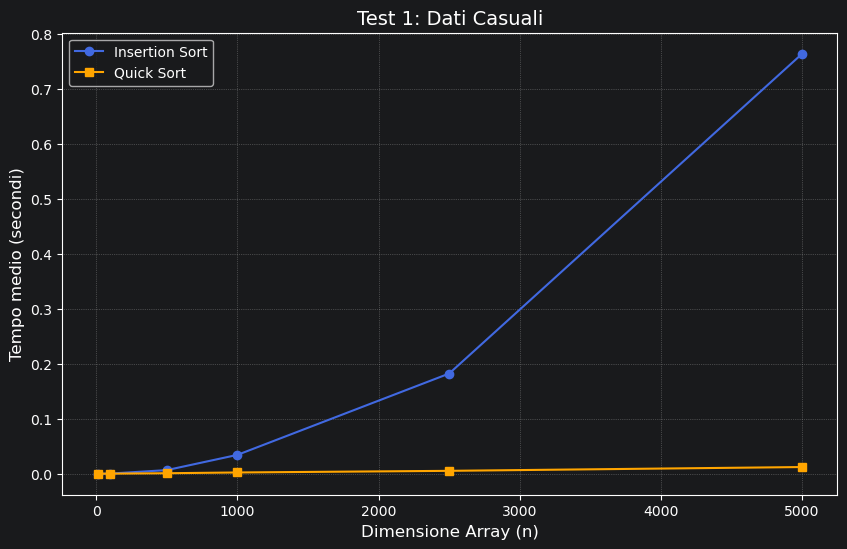

In [6]:
main(dim, "random", "Test 1: Dati Casuali")

**Analisi**: Il grafico mostra il comportamento nel caso medio. L'**Insertion Sort** segue una curva palesemente quadratica $O(N^2)$, mentre il **Quick Sort** mantiene una traiettoria quasi lineare $O(N \log N)$, staccando nettamente l'avversario all'aumentare della dimensione dell'array.

#### **3.3.2 Test su Dati Ordinati**
Qui testiamo gli algoritmi fornendo in input un array i cui elementi sono già disposti in perfetto ordine crescente.

Avvio benchmark: tipo dati = sorted


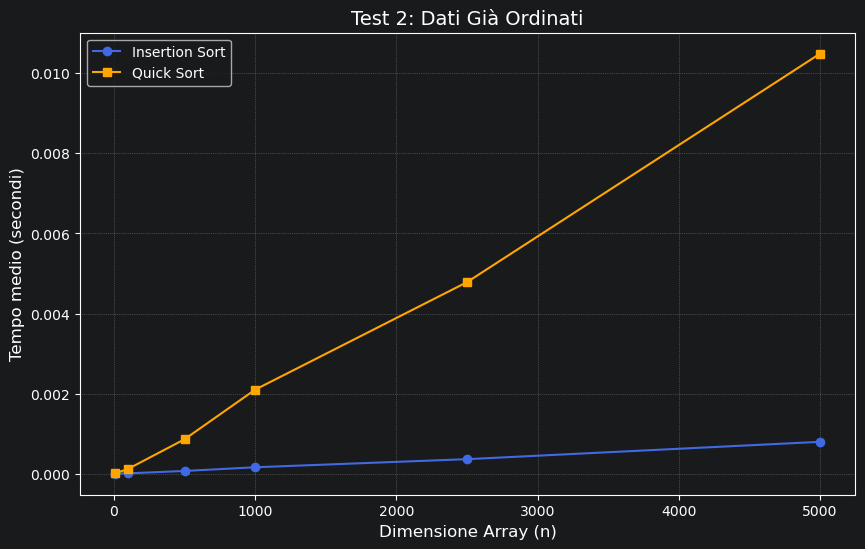

In [7]:
main(dim, "sorted", "Test 2: Dati Già Ordinati")

**Analisi**: Questo è il *Caso Ottimo* (Best Case) per l'**Insertion Sort**, che non dovendo effettuare alcuno spostamento termina istantaneamente in tempo lineare $O(N)$, battendo addirittura il **Quick Sort** (che subisce il leggero overhead delle chiamate ricorsive).

#### **3.3.3 Test su Dati Quasi Ordinati**
In questo test partiamo da un array ordinato per poi scambiare casualmente di posto solo il 5% dei suoi elementi. È una simulazione molto utile per testare i database del mondo reale che subiscono lievi perturbazioni e aggiornamenti.

Avvio benchmark: tipo dati = nearly_sorted


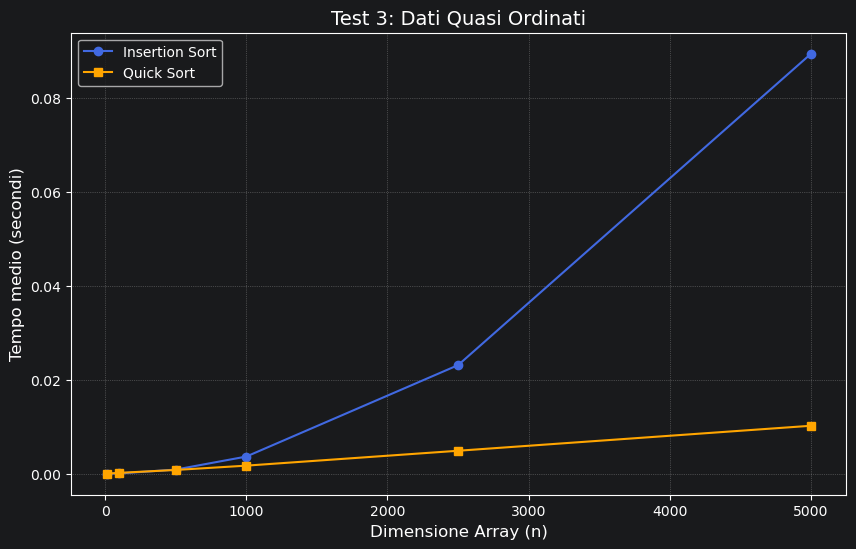

In [8]:
main(dim, "nearly_sorted", "Test 3: Dati Quasi Ordinati")

**Analisi**: Anche con una piccola percentuale di elementi fuori posto, l'**Insertion Sort** si conferma estremamente efficiente e competitivo, dimostrandosi un ottimo algoritmo *adattivo*. Il **Quick Sort** mantiene le sue solidissime prestazioni medie.

#### **3.3.4 Test su Dati Ordinati Inversamente**
Un vero e proprio test di stress: l'array fornito è ordinato in senso strettamente decrescente (dal valore più grande al più piccolo).

Avvio benchmark: tipo dati = reverse


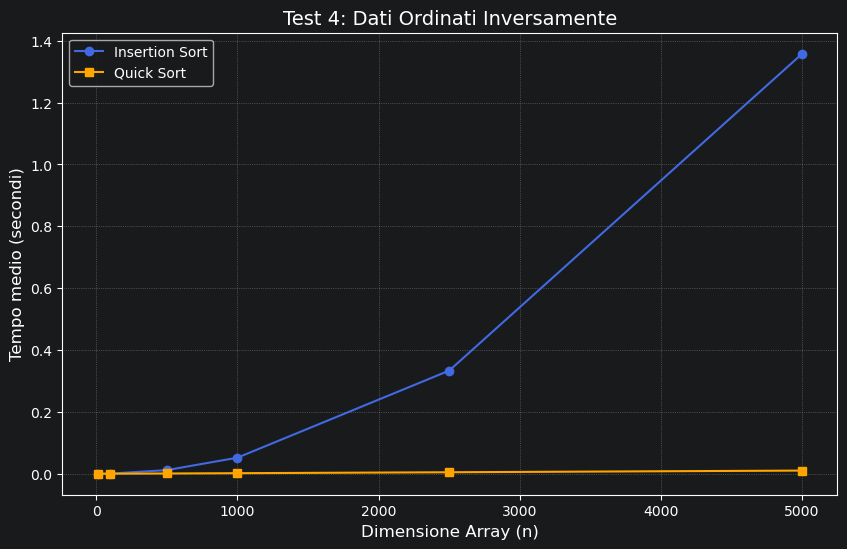

In [9]:
main(dim, "reverse", "Test 4: Dati Ordinati Inversamente")

**Analisi**: Il grafico mostra il *Caso Pessimo* (Worst Case) assoluto per l'**Insertion Sort**. Ogni nuovo elemento deve essere traslato fino all'inizio dell'array, massimizzando il numero di operazioni ($O(N^2)$). Il **Quick Sort** invece, grazie al trucco del pivot casuale, non si fa ingannare dall'ordine inverso e risolve il problema velocemente in $O(N \log N)$.

#### **3.3.5 Test su Dati Fortemente Raggruppati (Clustered)**
Eseguiamo un test su array contenenti migliaia di elementi, pescati però da un bacino artificiale di soli 10 valori unici. Avremo decine di blocchi di numeri identici mischiati fra loro.

Avvio benchmark: tipo dati = clustered


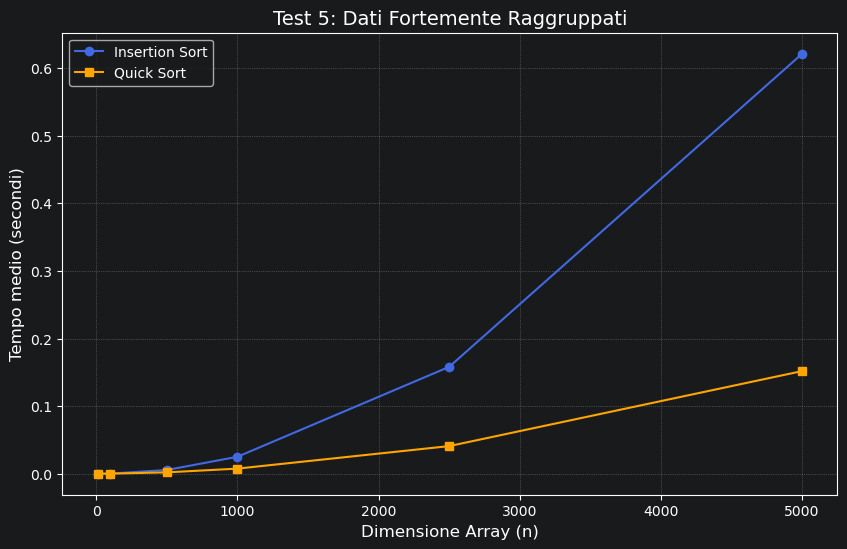

In [10]:
main(dim, "clustered", "Test 5: Dati Fortemente Raggruppati")

**Analisi**: In presenza di moltissimi duplicati (Clustered), le continue collisioni costringono l'**Insertion Sort** a continui spostamenti, degradando le prestazioni. Il **Quick Sort** continua a dominare incontrastato.

#### **3.3.6 Test su Dati Tutti Uguali (Caso Pessimo Quick Sort)**
Infine, l'anomalia estrema: forniamo in input un array composto esclusivamente dallo stesso identico valore ripetuto per $N$ volte (nessun numero è maggiore o minore degli altri).

Avvio benchmark: tipo dati = all_equal


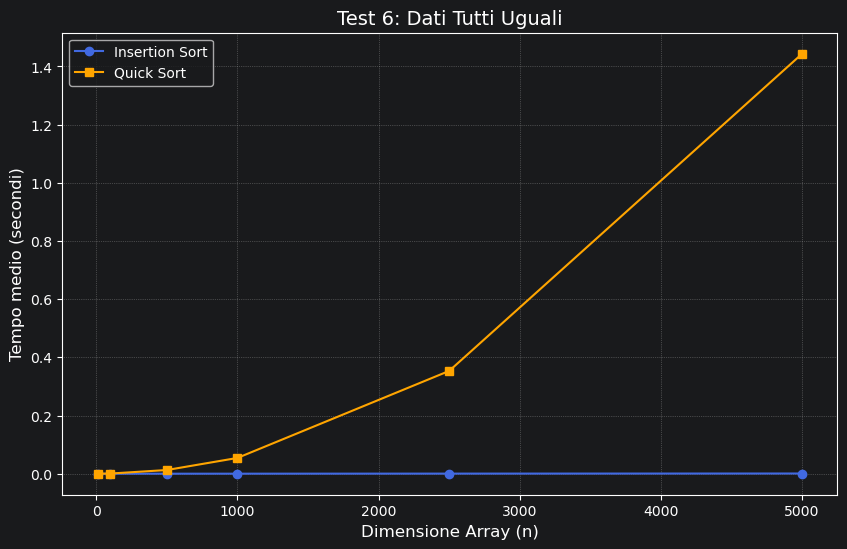

In [11]:
main(dim, "all_equal", "Test 6: Dati Tutti Uguali")

**Analisi**: Questo grafico mostra il vero *Tallone d'Achille* del **Quick Sort**. In questo scenario estremo con valori tutti identici, lo schema di partizione di *Lomuto* fallisce nel dividere l'array, facendo scivolare l'algoritmo nel suo famigerato caso pessimo teorico $O(N^2)$. L'**Insertion Sort**, viceversa, vede l'array come già ordinato e conclude la gara in una frazione di millisecondo ($O(N)$).

## **4. Conclusioni**

Dai risultati sperimentali si evince chiaramente come l'**Insertion Sort** sia estremamente sensibile all'ordinamento iniziale dei dati:
1. Trionfa negli scenari di **Dati Già Ordinati** (o *Quasi Ordinati*), dove completando in tempo lineare $O(N)$ batte persino il Quick Sort (che soffre del leggero costo aggiuntivo della ricorsione).
2. Degrada pesantemente ($O(N^2)$) nei casi di **Dati Casuali** e raggiunge il suo caso pessimo assoluto con **Dati Ordinati Inversamente**.

Il **Quick Sort**, d'altra parte, si dimostra incredibilmente **robusto e scalabile**:
1. Grazie alla scelta del **pivot casuale**, mantiene la sua complessità media $O(N \log N)$ su quasi tutti gli scenari, ignorando l'ordine iniziale dei dati.
2. Il suo **vero tallone d'Achille** (Caso Pessimo) si è rivelato nello scenario *Tutti Uguali*. Anche pescando un pivot casuale, se tutti gli elementi sono identici il partizionamento non riesce mai a dividere l'array a metà. Creerà sempre una partizione vuota e una contenente tutti gli altri elementi. Questa sbilanciatura estrema fa crollare inesorabilmente le prestazioni a $O(N^2)$.
3. L'unica altra debolezza rispetto all'Insertion Sort si verifica sui vettori molto piccoli e già ordinati, dove il Quick Sort spreca tempo prezioso a causa del partizionamento e delle numerose chiamate ricorsive.

**Verdetto Finale**: L'Insertion Sort è consigliabile solo per array di dimensioni minuscole o in scenari dove si ha la garanzia che l'array sia già quasi del tutto in ordine. In ogni altro caso generale, il Quick Sort domina garantendo prestazioni di ordini di grandezza superiori.